# 03 — Multihypothesis Extension Benchmarks

Exploratory extension to N=3,5,10 known simple hypotheses. It tests the appendix intuition and hard-alternative switching, but does not claim the binary matched theorem extends unchanged.

**Execution modes:** `SMOKE_TEST=1` performs a small offline code-path check; default settings run a moderate benchmark; `FULL_RUN=1` enables publication-scale Monte Carlo. Smoke outputs are verification-only and must not be reported as experimental results.

In [1]:
from pathlib import Path
import os, sys, math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == 'notebooks' else HERE
if not (ROOT/'src'/'gated_benchmarks.py').exists():
    for cand in [HERE, *HERE.parents]:
        if (cand/'src'/'gated_benchmarks.py').exists():
            ROOT = cand; break
sys.path.insert(0, str(ROOT/'src'))
( ROOT/'results').mkdir(exist_ok=True)
( ROOT/'figures').mkdir(exist_ok=True)
FULL_RUN = os.getenv('FULL_RUN','0') == '1'
SMOKE_TEST = os.getenv('SMOKE_TEST','0') == '1'
print('ROOT =', ROOT)
print('FULL_RUN =', FULL_RUN, 'SMOKE_TEST =', SMOKE_TEST)


ROOT = /mnt/data/gated_certification_benchmarks
FULL_RUN = False SMOKE_TEST = True


In [2]:
from gated_benchmarks import *


## 1. Inspect uniformly-hardest and switching constructions

In [3]:
def closest_to_h0(probs, action):
    vals=[]
    for j in range(1,len(probs)):
        vals.append((j,kl_bernoulli(probs[0,action],probs[j,action])))
    return min(vals,key=lambda z:z[1]), vals
for N in [3,5,10]:
    for mode in ['uniform_hardest','switching']:
        p=generate_multihyp_bernoulli_probs(N,mode)
        print()
        print('N=',N,'mode=',mode,'weak closest=',closest_to_h0(p,0)[0],'strong closest=',closest_to_h0(p,1)[0])
        print(p)



N= 3 mode= uniform_hardest weak closest= (1, 0.2704380927539544) strong closest= (1, 0.4946319372140727)
[[0.15 0.05]
 [0.5  0.5 ]
 [0.85 0.95]]

N= 3 mode= switching weak closest= (1, 0.012966691013252263) strong closest= (2, 0.012966691013252263)
[[0.5  0.5 ]
 [0.58 0.9 ]
 [0.1  0.58]]

N= 5 mode= uniform_hardest weak closest= (1, 0.07996662658503509) strong closest= (1, 0.17153840864099468)
[[0.15  0.05 ]
 [0.325 0.275]
 [0.5   0.5  ]
 [0.675 0.725]
 [0.85  0.95 ]]

N= 5 mode= switching weak closest= (1, 0.012966691013252263) strong closest= (2, 0.012966691013252263)
[[0.5  0.5 ]
 [0.58 0.9 ]
 [0.1  0.58]
 [0.15 0.85]
 [0.85 0.15]]

N= 10 mode= uniform_hardest weak closest= (1, 0.018909109917485206) strong closest= (1, 0.0507337389213077)
[[0.15       0.05      ]
 [0.22777778 0.15      ]
 [0.30555556 0.25      ]
 [0.38333333 0.35      ]
 [0.46111111 0.45      ]
 [0.53888889 0.55      ]
 [0.61666667 0.65      ]
 [0.69444444 0.75      ]
 [0.77222222 0.85      ]
 [0.85       0.95     

## 2. Sequential multiway benchmark

In [4]:
Ns=[3,5,10]; modes=['uniform_hardest','switching']; policies=['gated','oracle','weak_only']; delta=.05; alpha=.05
n_trials=5 if SMOKE_TEST else (60 if not FULL_RUN else 500)
rows=[]
for N in Ns:
    for mode in modes:
        probs=generate_multihyp_bernoulli_probs(N,mode)
        # H0 tests the gated path; H1 and H2 test false unlocking and alternative discrimination.
        hs=list(range(min(N,3)))
        for h in hs:
            for pol in policies:
                df=simulate_multihypothesis_gate(probs,h,delta=delta,alpha=alpha,n_trials=n_trials,seed=100*N+10*h+policies.index(pol),policy=pol,max_steps=(3000 if SMOKE_TEST else 10000))
                rows.append({'N':N,'mode':mode,'true_h':h,'policy':pol,'mean_tau':df.tau.mean(),'median_tau':df.tau.median(),'q95_tau':df.tau.quantile(.95),'error_rate':df.error.mean(),'false_unlock':df.false_unlock.mean(),'mean_Nweak':df.Nweak.mean(),'mean_Nstrong':df.Nstrong.mean()})
res=pd.DataFrame(rows); display(res); res.to_csv(ROOT/'results'/'multihypothesis_benchmark.csv',index=False)


,N,mode,true_h,policy,mean_tau,median_tau,q95_tau,error_rate,false_unlock,mean_Nweak,mean_Nstrong
0,3,uniform_hardest,0,gated,18.2,12.0,41.8,0.2,0.0,16.4,1.8
1,3,uniform_hardest,0,oracle,8.8,6.0,14.2,0.0,0.0,0.0,8.8
2,3,uniform_hardest,0,weak_only,13.8,14.0,17.0,0.0,0.0,13.8,0.0
3,3,uniform_hardest,1,gated,20.6,15.0,37.4,0.0,0.0,20.6,0.0
4,3,uniform_hardest,1,oracle,10.0,8.0,18.4,0.0,1.0,0.0,10.0
5,3,uniform_hardest,1,weak_only,19.4,19.0,29.0,0.0,0.0,19.4,0.0
6,3,uniform_hardest,2,gated,15.2,17.0,23.4,0.0,0.0,15.2,0.0
7,3,uniform_hardest,2,oracle,8.8,6.0,14.2,0.0,1.0,0.0,8.8
8,3,uniform_hardest,2,weak_only,11.4,11.0,14.0,0.0,0.0,11.4,0.0
9,3,switching,0,gated,268.2,252.0,539.0,0.0,0.0,266.8,1.4


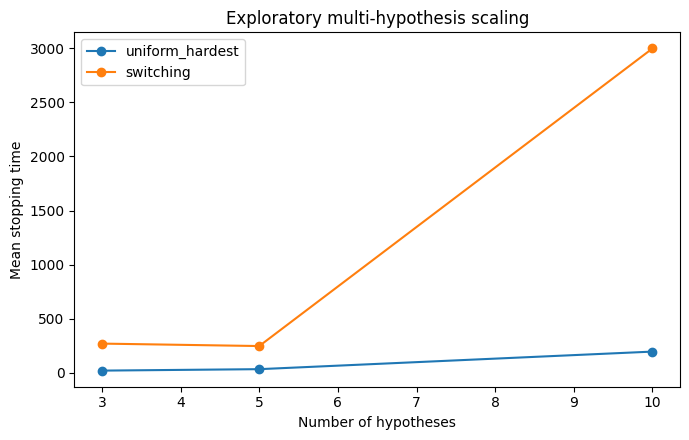

In [5]:
q=res[(res.true_h==0)&(res.policy=='gated')]
fig,ax=plt.subplots(figsize=(7,4.5))
for mode in modes:
    z=q[q['mode']==mode]; ax.plot(z.N,z.mean_tau,marker='o',label=mode)
ax.set_xlabel('Number of hypotheses'); ax.set_ylabel('Mean stopping time'); ax.set_title('Exploratory multi-hypothesis scaling'); ax.legend(); fig.tight_layout(); fig.savefig(ROOT/'figures'/'multihypothesis_scaling.png',dpi=180); plt.show()


## 3. What this adds to the paper
- `uniform_hardest` numerically checks the appendix regime where one alternative remains hardest across actions.
- `switching` deliberately violates that simplifying condition: the closest alternative changes between weak and strong actions.
- The experiment reports how a pairwise-LLR gated rule behaves, but **does not claim matching optimality** in this general setting. A strong result here would motivate a future theorem rather than silently expanding the current theorem.